# Fraud Detection for Vehicle Insurance Claims  

## 1. Источник данных и почему выбран

Используется датасет **Vehicle Insurance Claim Fraud Detection**.

(https://www.kaggle.com/datasets/shivamb/vehicle-claim-fraud-detection/data) 

Это табличный датасет для задачи классификации. Нужно предсказать, является ли страховая заявка мошеннической (FraudFound_P = 1).

Почему выбрал этот датасет:
- реальная прикладная задача, которую еще не выбрали.
- есть смешанные признаки: категориальные и числовые.
- есть дисбаланс классов, что делает выбор метрик осмысленным.
- достаточный размер сравнения нескольких моделей.



In [37]:
# Определяем корень проекта и путь к исходному датасету.
from pathlib import Path


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Не удалось найти корень проекта (ожидались папки src и data).')


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'fraud_oracle.csv'

print('Используемый файл:', DATA_PATH.as_posix())

Используемый файл: c:/Users/Владислав/Desktop/ML/test/hseml-group-project-c0ldesty/data/raw/fraud_oracle.csv


## 2. Импорты, линтеры и воспроизводимость

In [38]:
# Импортируем библиотеки и фиксируем случайность для воспроизводимости.
import os
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.decomposition import TruncatedSVD

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Fixed seed =", RANDOM_STATE)

Fixed seed = 42


## 3. Загрузка данных и первичный обзор

In [39]:
# Загружаем исходный датасет и выводим первые строки для первичного просмотра.
df = pd.read_csv(DATA_PATH)

print("Размер датасета:", df.shape)
display(df.head())

Размер датасета: (15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [40]:
# Смотрим типы, дубликаты, пропуски и распределение целевого признака.
print("Типы данных:")
display(df.dtypes.to_frame("dtype").T)

print("\nЧисло полных дублей:", df.duplicated().sum())

print("\nПропуски до очистки:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count").head(15))

target_col = "FraudFound_P"
print("\nРаспределение target:")
display(df[target_col].value_counts().rename("count").to_frame())
print("Доля fraud:", round(df[target_col].mean(), 4))

Типы данных:


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
dtype,object,int64,object,object,object,object,object,int64,object,object,...,object,object,object,object,object,object,object,object,int64,object



Число полных дублей: 0

Пропуски до очистки:


,missing_count
Month,0
WeekOfMonth,0
DayOfWeek,0
Make,0
AccidentArea,0
DayOfWeekClaimed,0
MonthClaimed,0
WeekOfMonthClaimed,0
Sex,0
MaritalStatus,0



Распределение target:


,count
FraudFound_P,
0,14497
1,923


Доля fraud: 0.0599


### Описание датасета

Итого исходный датасет содержит **15420 строк** и **33 столбца**. Каждая строка соответствует одной страховой заявке.

Целевая переменная — **`FraudFound_P`**, где `1` означает мошеннический случай, а `0` — обычную заявку.

В таблице представлены как категориальные, так и числовые признаки: характеристики клиента, автомобиля, полиса и самого страхового случая. Используются признаки, связанные с местом происшествия, типом полиса, возрастом страхователя, размером франшизы, наличием свидетеля и полицейского отчёта.

Датасет несбалансирован: мошеннических случаев заметно меньше, чем обычных, поэтому при оценке моделей важно смотреть не только на `accuracy`, но и на метрики, чувствительные к редкому положительному классу.

## 4. Очистка данных

На этапе очистки приводим датасет к рабочему виду для дальнейшего анализа и baseline-моделей.

- `PolicyNumber` и `RepNumber` удаляем, потому что это служебные идентификаторы, а не содержательные признаки.
- Строки с `MonthClaimed == '0'` убираем как некорректные служебные значения.
- Значение `Age == 0` заменяем на `16.5`, чтобы убрать явную аномалию в возрасте (ставим 16.5, так как это данные из группы возрастов 16-17).
- Полные дубликаты удаляем.

In [41]:
# Очищаем данные и сохраняем очищенный датасет в processed.
clean_df = df.copy()

print("Размер до очистки:", clean_df.shape)

clean_df = clean_df.drop(columns=["PolicyNumber", "RepNumber"])

print("Строки с DayOfWeekClaimed == '0':")
display(clean_df[clean_df["DayOfWeekClaimed"] == "0"])

print("Строки с MonthClaimed == '0':")
display(clean_df[clean_df["MonthClaimed"] == "0"])

print("AgeOfPolicyHolder для строк, где Age == 0:")
display(clean_df[clean_df["Age"] == 0]["AgeOfPolicyHolder"].value_counts())

clean_df = clean_df[clean_df["MonthClaimed"] != "0"].copy()
clean_df["Age"] = clean_df["Age"].replace({0: 16.5})

clean_df = clean_df.drop_duplicates().reset_index(drop=True)

print("Размер после очистки:", clean_df.shape)
print("\nПроверка после очистки:")
print("MonthClaimed == '0':", (clean_df["MonthClaimed"] == "0").sum())
print("Age == 0:", (clean_df["Age"] == 0).sum())

processed_dir = PROJECT_ROOT / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)
clean_path = processed_dir / 'fraud_oracle_clean.csv'
clean_df.to_csv(clean_path, index=False)
print('Сохранено:', clean_path.as_posix())

Размер до очистки: (15420, 33)
Строки с DayOfWeekClaimed == '0':


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
1516,Jul,2,Monday,Honda,Rural,0,0,1,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,All Perils


Строки с MonthClaimed == '0':


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
1516,Jul,2,Monday,Honda,Rural,0,0,1,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,All Perils


AgeOfPolicyHolder для строк, где Age == 0:


AgeOfPolicyHolder
16 to 17    320
Name: count, dtype: int64

Размер после очистки: (15419, 31)

Проверка после очистки:
MonthClaimed == '0': 0
Age == 0: 0
Сохранено: c:/Users/Владислав/Desktop/ML/test/hseml-group-project-c0ldesty/data/processed/fraud_oracle_clean.csv


## 5. EDA: исследование данных и зависимостей

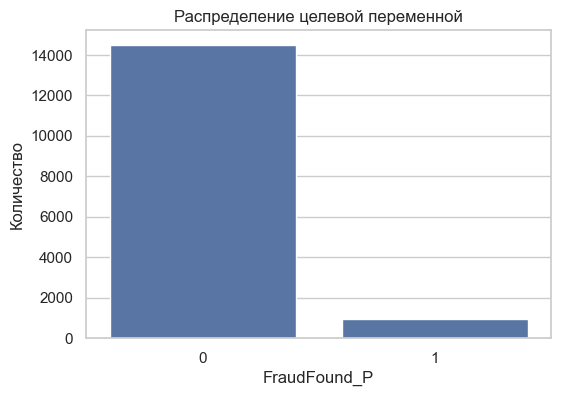

In [42]:
# Строим график распределения целевой переменной.
plt.figure(figsize=(6, 4))
sns.countplot(x=clean_df[target_col].astype(str))
plt.title("Распределение целевой переменной")
plt.xlabel("FraudFound_P")
plt.ylabel("Количество")
plt.show()

In [43]:
# Проверяем распределения выбранных числовых признаков.
for col in ["Deductible", "DriverRating", "Year", "Age"]:
    display(clean_df[col].value_counts().sort_index())

Deductible
300        8
400    14837
500      263
700      311
Name: count, dtype: int64

DriverRating
1    3944
2    3800
3    3884
4    3791
Name: count, dtype: int64

Year
1994    6141
1995    5195
1996    4083
Name: count, dtype: int64

Age
16.0      9
16.5    319
17.0      6
18.0     48
19.0     32
       ... 
76.0     42
77.0     29
78.0     35
79.0     20
80.0     32
Name: count, Length: 66, dtype: int64

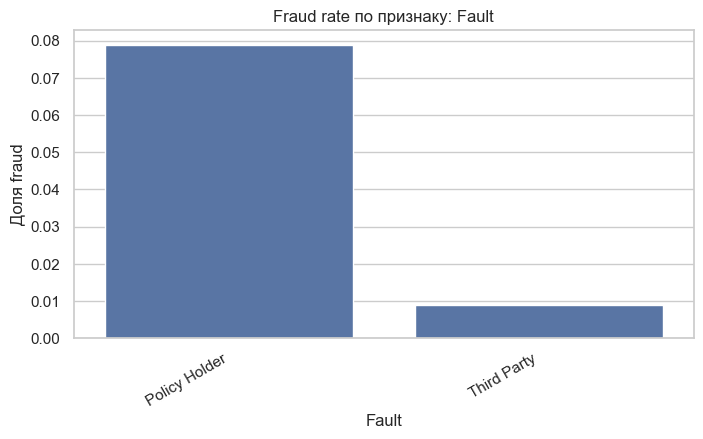

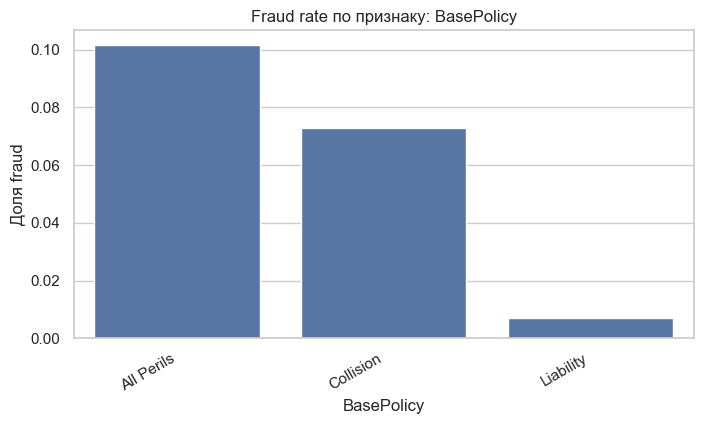

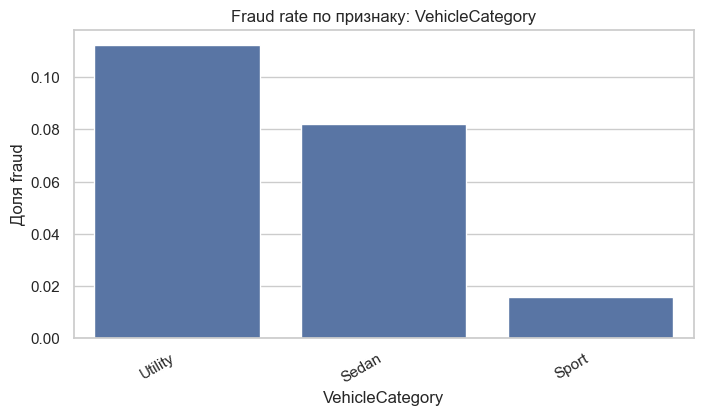

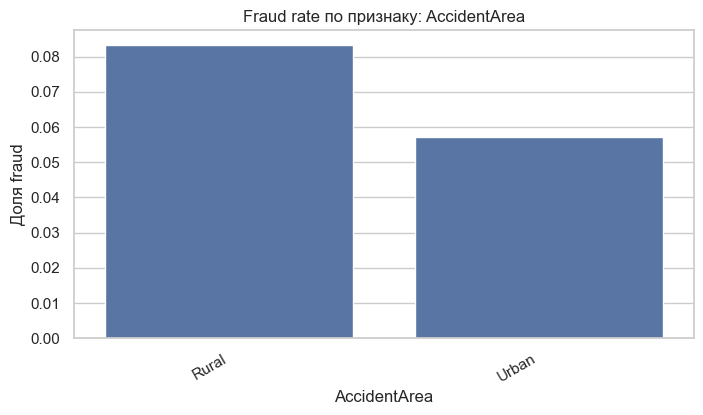

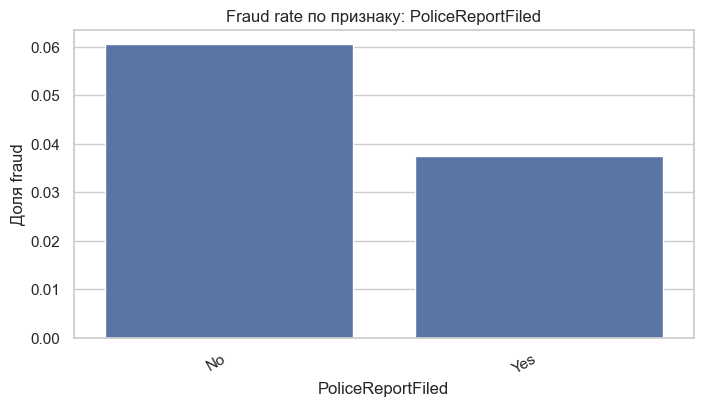

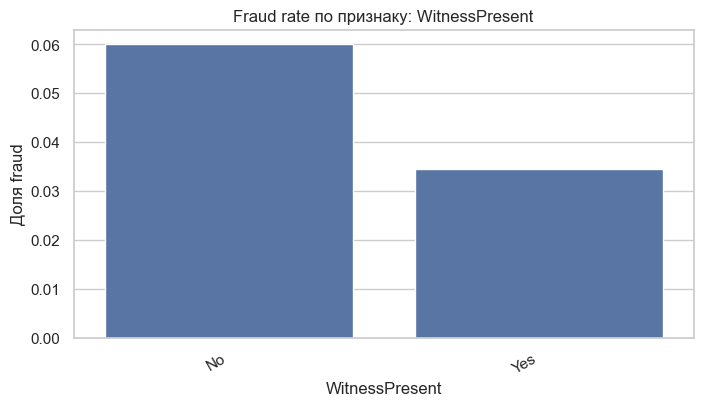

In [44]:
# Строим fraud rate по ключевым категориальным признакам.
eda_cat_cols = [
    "Fault",
    "BasePolicy",
    "VehicleCategory",
    "AccidentArea",
    "PoliceReportFiled",
    "WitnessPresent",
]

for col in eda_cat_cols:
    fraud_rate = clean_df.groupby(col)[target_col].mean().sort_values(ascending=False)

    plt.figure(figsize=(8, 4))
    sns.barplot(x=fraud_rate.index, y=fraud_rate.values)
    plt.title(f"Fraud rate по признаку: {col}")
    plt.ylabel("Доля fraud")
    plt.xticks(rotation=30, ha="right")
    plt.show()

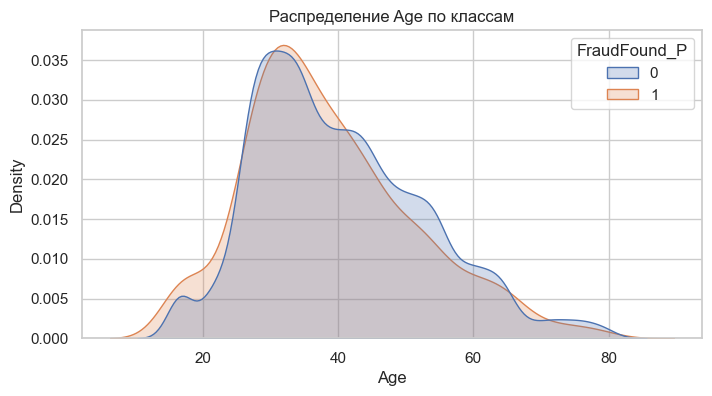

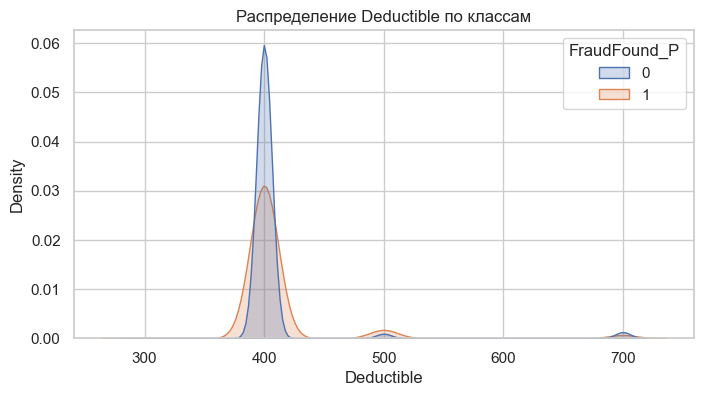

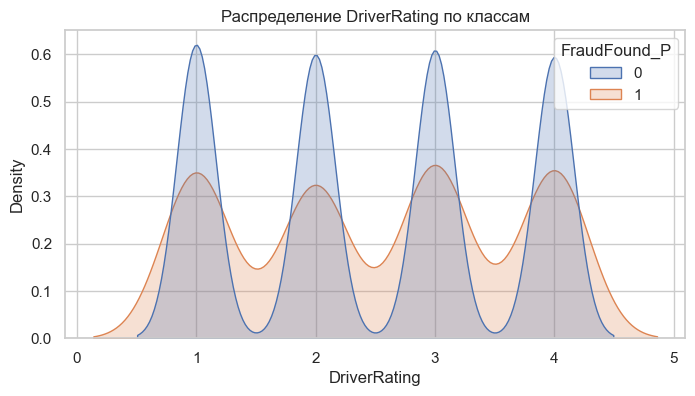

In [45]:
# Сравниваем распределения числовых признаков по классам через KDE.
for col in ["Age", "Deductible", "DriverRating"]:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=clean_df, x=col, hue=target_col, common_norm=False, fill=True)
    plt.title(f"Распределение {col} по классам")
    plt.show()

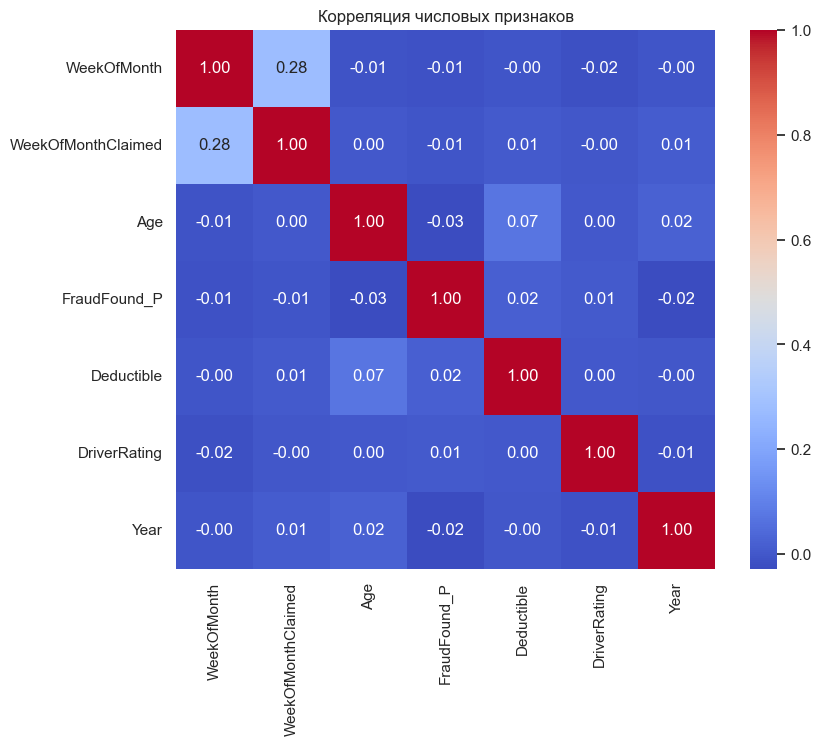

In [46]:
# Строим корреляционную матрицу по числовым признакам.
corr = clean_df.select_dtypes(include="number").corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Корреляция числовых признаков")
plt.show()

### Вывод по EDA

Как уже было известно, по графику целевой переменной также видно, что датасет несбалансирован: случаев fraud заметно меньше, чем обычных заявок. Это значит, что при дальнейшем сравнении моделей нужно будет использовать метрики, которые учитывают сильный дизбаланс классов.

Графики по категориальным признакам показывают, что доля fraud различается между группами. Наиболее полезными для модели выглядят признаки, связанные с виновностью в ДТП (Fault), типом полиса (BasePolicy), категорией автомобиля (VehicleCategory), зоной происшествия (AccidentArea), а также наличием полицейского отчёта и свидетеля.

По распределениям числовых признаков видно, что сами по себе они не дают очень чёткого разделения классов, но всё же могут нести полезный сигнал в комбинации с категориальными признаками. Корреляционная матрица также показывает, что сильной линейной зависимости между числовыми признаками нет, поэтому основной вклад в качество модели, вероятно, будут давать сочетания признаков и категориальные переменные.

## 6. Подготовка признаков и feature engineering

Я попробую проверить feature engineering уже в cp1. Так что после очистки данных добавляю несколько новых признаков, которые можно интерпретировать содержательно и использовать в baseline-моделях.

Созданные признаки:

- `HasPoliceReport` — бинарный признак наличия полицейского отчёта. Такой признак может быть полезен, потому что наличие официальной фиксации происшествия может быть связано с характером страхового случая.
- `HasWitness` — бинарный признак наличия свидетеля. Он добавлен как потенциальный индикатор того, насколько событие подтверждается внешними наблюдателями.
- `IsUrban` — бинаризация признака AccidentArea. Разделение на городской и негородской случай может помочь модели уловить различия в типичных сценариях страховых заявок.
- `Age_ClaimGap` — комбинация AgeOfVehicle и AgeOfPolicyHolder. Здесь мы явно кодируем совместный эффект возраста автомобиля и возрастной категории страхователя.
- `Policy_Claim_Month_Same` — признак совпадения месяца события и месяца подачи заявления. Он нужен для проверки гипотезы, что задержка между происшествием и обращением может быть информативной.
- `WeekendLikeClaim` — бинарный признак для заявок, поданных в выходные (Saturday, Sunday). Такой признак может отражать особенности поведения заявителей по дням недели.

Эти признаки не требуют внешних данных, легко объясняются и подходят для первого этапа сравнения моделей.

In [47]:
# Печатаем список и количество признаков после очистки.
print("Количество столбцов после очистки:", clean_df.shape[1])
print("Список столбцов:")
print(clean_df.columns.tolist())

Количество столбцов после очистки: 31
Список столбцов:
['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']


In [48]:
# Создаем engineered признаки и сохраняем итоговый FE-датасет в processed.
fe_df = clean_df.copy()

fe_df["HasPoliceReport"] = (fe_df["PoliceReportFiled"] == "Yes").astype(int)
fe_df["HasWitness"] = (fe_df["WitnessPresent"] == "Yes").astype(int)
fe_df["IsUrban"] = (fe_df["AccidentArea"] == "Urban").astype(int)
fe_df["Age_ClaimGap"] = fe_df["AgeOfVehicle"] + "__" + fe_df["AgeOfPolicyHolder"]
fe_df["Policy_Claim_Month_Same"] = (fe_df["Month"] == fe_df["MonthClaimed"]).astype(int)
fe_df["WeekendLikeClaim"] = fe_df["DayOfWeekClaimed"].isin(["Saturday", "Sunday"]).astype(int)

print("Количество столбцов после feature engineering:", fe_df.shape[1])
new_cols = sorted(set(fe_df.columns) - set(clean_df.columns))
print("Новые признаки:")
print(new_cols)

processed_dir = PROJECT_ROOT / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)
fe_path = processed_dir / 'fraud_oracle_fe.csv'
fe_df.to_csv(fe_path, index=False)
print('Сохранено:', fe_path.as_posix())

Количество столбцов после feature engineering: 37
Новые признаки:
['Age_ClaimGap', 'HasPoliceReport', 'HasWitness', 'IsUrban', 'Policy_Claim_Month_Same', 'WeekendLikeClaim']
Сохранено: c:/Users/Владислав/Desktop/ML/test/hseml-group-project-c0ldesty/data/processed/fraud_oracle_fe.csv
